# **Análisis de fuerzas en simulación Parcelas**
---
## *Subcoordinación de Posgrado y Educación Continua.*
### [Instituto Mexicano de Tecnología del Agua](https://www.gob.mx/imta).<br>

<img src="./Datos/Imagenes/Logos.png" height="100" align="middle">

**Tutor: Dr. Ariosto Aguilar Chávez** <br>
**Tutorados: M.en C. Michell Deyanira Cruz Santiago , M. en C. Gibrán Mubarqui Guevara, Ing. Elizabeth Rosario Hernández Barrientos, Ing. Omar Ulises Robles Pereyra**<br>


[![Open In Colab](./Datos/Imagenes/colab-badge.svg)](https://colab.research.google.com/github/OmarURP/Toolbox_publica/blob/main/08_Parcelas.ipynb)

---

In [1]:
# Carga de librerías
import ImtaTURB as imta
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# === Función auxiliar: Cp promedio vs theta ===
def cp_promedio_por_theta(p_probes, probes_ordenados, rho, U_inf, t_ini=None):
    series_p = []
    for prb in probes_ordenados:
        p_i, t_i, _ = imta.recortar_tiempo(
            p_probes, probe=prb,
            inicio=tiempo_p.iloc[0] if t_ini is None else t_ini
        )
        series_p.append(p_i.values)

    p_theta = np.vstack(series_p).T  # (n_tiempos, n_angulos)
    p_pa = rho * p_theta             # convertir a Pa (p en m^2/s^2)

    # Promedio temporal por ángulo
    p_mean = np.mean(p_pa, axis=0)

    # Cp = p / (0.5*rho*U_inf^2) (sin p_inf)
    q = 0.5 * rho * U_inf**2
    Cp = p_mean / q

    return Cp, p_pa

In [3]:
# Carga de datos
file_p = "Datos/OpenFOAM/20_cm/p"
file_U = "Datos/OpenFOAM/20_cm/U"
# Ventana de tiempo
inicio = 50 # Ignorando arranque en caliente
# Probe a analizar
probe_1 = 0
# Datos para cálculos
rho = 1000.0   # kg/m^3
U_inf = 0.177  # m/s
D = 0.05       # m
R = D / 2      # m
span = 0.26    # m (altura de la pila)

In [4]:
# Procesar p, U y nut
p_probes, tiempo_p, coords_p, fs_p = imta.cargar_p_OpenFOAM(file_p)
U_probes, tiempo_U, coords_U, fs_U = imta.cargar_U_OpenFOAM(file_U)

c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)
c:\Users\Public\Winpython\WPy64-31241\notebooks\Toolbox_publica\.venv\Lib\site-packages\pandas\core\dtypes\astype.py:133: RuntimeWarning: overflow encountered in cast
  return arr.astype(dtype, copy=True)


Se extrajeron 167 probes.
Tiempo inicial: 200.00 s, tiempo final: 220.00 s
Duración de la muestra: 20.00 s
Frecuencia de muestreo: 100.00 Hz (Δt = 0.0100 s)


In [5]:
# Creación de vector con ángulos
angulos_deg = np.arange(0, 360, 10) 
num_cil = 4 
allprobes = np.arange(0, num_cil, 1) 

# 1. Inicializar el diccionario vacío
cilindros = {}

for probe_i in allprobes:
    # Nota: Simplifiqué un poco la multiplicación matemática del límite superior
    puntos_i = list(range(probe_i * angulos_deg.size, (probe_i + 1) * angulos_deg.size))
    
    # 2. Guardar la lista en el diccionario usando probe_i como clave
    cilindros[probe_i] = puntos_i

# Prueba de acceso:
print("Puntos del cilindro 1:")
print(cilindros[0])
print("Puntos del cilindro -1:")
print(cilindros[num_cil-1])

Puntos del cilindro 1:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]
Puntos del cilindro -1:
[108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143]


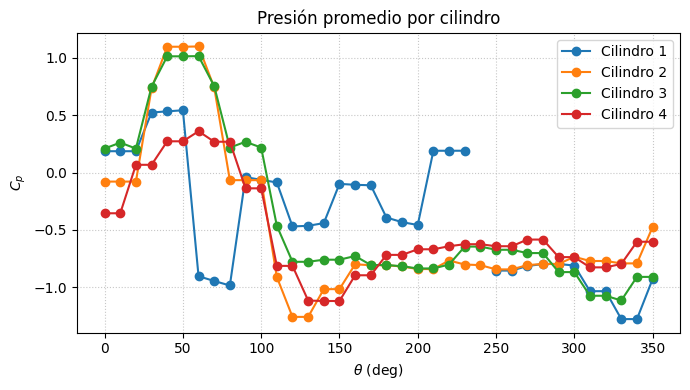

In [12]:
# Declaración de diccionarios
Cp = {}
p_pa = {}

# Ciclo para calcular Cp y p_pa por cada cilindro
for i in cilindros.keys():
    # Uso de función cp_promedio_por_theta
    Cp[i], p_pa[i] = cp_promedio_por_theta(p_probes, cilindros[i], rho, U_inf, t_ini=210)

# Graficando serie para pada Cp
plt.figure(figsize=(7, 4))

for i in Cp.keys():
    plt.plot(angulos_deg, Cp[i], 'o-', label=f'Cilindro {i+1}')

plt.xlabel(r'$\theta$ (deg)')
plt.ylabel(r'$C_p$')
plt.title('Presión promedio por cilindro')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()